# ANALISIS Y PROCESAMIENTO DE SEÑALES
## Trabajo Práctico N°0
### Aylin Cano

En este trabajo se diseñó una función generadora de señales senoidales digitalizadas, parametrizable en amplitud, valor medio, frecuencia, fase, cantidad de muestras y frecuencia de muestreo. Luego se probó con distintas frecuencias para observar su comportamiento.

importo las librerias y defino la frecuencia de muestreo, la cantidad de muestras y el tiempo de cada muestra que se utilizara para gwnerar señales 

In [4]:
#importacion de librerias
import numpy as np
import matplotlib.pyplot as plt

#defino parametros
fs=1000 #Hz
N=1000 #muestras
ts= 1/ fs #espaciado entre muestras

Defino la función `mi_funcion_sen`, que genera una señal senoidal a partir de los parámetros indicados anteriormente.

In [5]:
def mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs):    
    
    ts= 1/ fs #tiempo entre cada muestra
    tt= np.arange(0,nn) *ts #tiempo de cada muestra, vector
    
    xx= dc + vmax*np.sin(2 * np.pi * ff * tt + ph)

    return(tt, xx)


con ff = 1 Hz genero una primera señal de prueba para verificar que la función funciona correctamente.

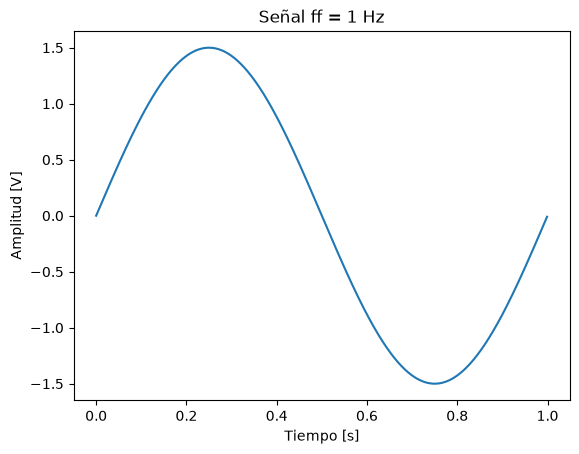

In [6]:
vmax = 1.5 #amplitud
dc=0 #desplazamiento
ff = 1
ph = 0
nn=N

tt= np.arange(0,nn) *ts
xx= dc + vmax*np.sin(2 * np.pi * ff * tt + ph)
tt, xx = mi_funcion_sen( vmax = 1.5 , dc = 0, ff = 1, ph=0, nn = N, fs = fs)


plt.plot(tt, xx)
plt.title("Señal ff = 1 Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.show()

El gráfico muestra un ciclo completo de la senoidal en el intervalo de 1 segundo, lo cual tiene sentido ya que la frecuencia elegida fue de 1 Hz. Además, se puede ver que la señal oscila entre -1.5 y 1.5, que corresponde a la amplitud máxima (vmax = 1.5) definida, y que su valor medio es 0 (dc = 0), ya que la señal está centrada en el eje horizontal.

A partir de acá pruebo la función con las frecuencias indicadas en la consigna, manteniendo fs = 1000 Hz y N = 1000 muestras.

### ff = 500 Hz

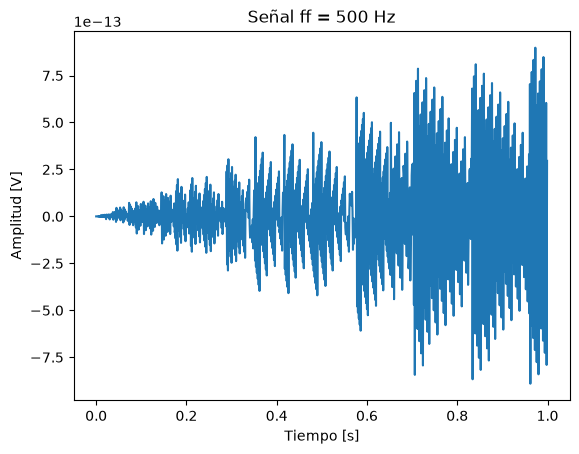

In [7]:
tt, xx = mi_funcion_sen( vmax = 1.5 , dc = 0, ff = 500, ph=0, nn = N, fs = fs)
plt.plot(tt, xx) 
plt.title("Señal ff = 500 Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.show()

Con ff = 500 Hz llegamos justo a fs/2 (frecuencia de Nyquist), el límite teórico para muestrear una señal. En este caso, las muestras caen justo donde la señal vale cero, por eso el gráfico da prácticamente todo cero (el 10⁻¹³ es solo error numérico de la computadora).

### ff = 999 Hz

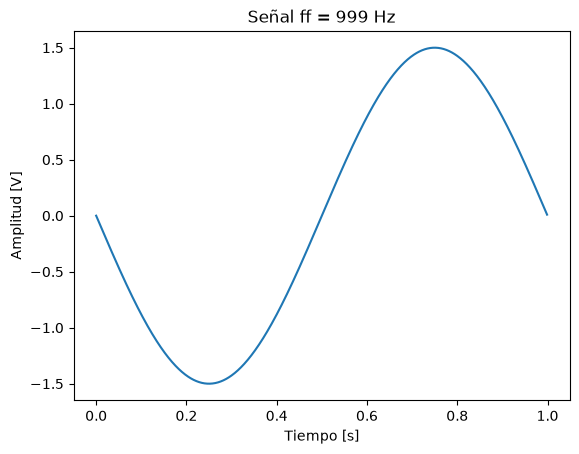

In [8]:
tt, xx = mi_funcion_sen( vmax = 1.5 , dc = 0, ff = 999, ph=0, nn = N, fs = fs)
plt.plot(tt, xx) 
plt.title("Señal ff = 999 Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.show()

Con ff = 999 Hz se supera la condición de Nyquist (fs/2 = 500 Hz), por lo que aparece aliasing: la señal se ve como si tuviera 1 Hz, ya que |999 − 1000| = 1.

### ff = 1001 Hz

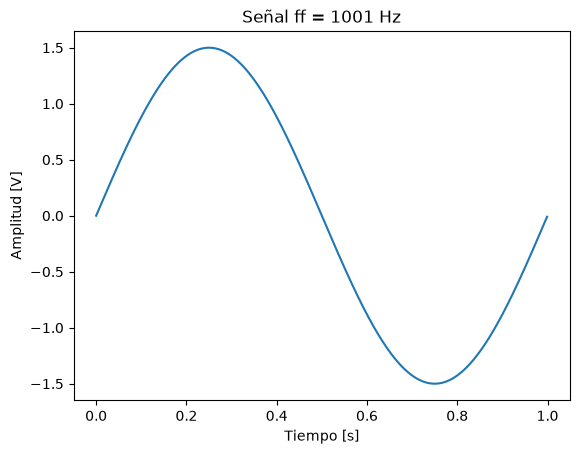

In [9]:
tt, xx = mi_funcion_sen( vmax = 1.5 , dc = 0, ff = 1001, ph=0, nn = N, fs = fs)
plt.plot(tt, xx) 
plt.title("Señal ff = 1001 Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.show()

Con ff = 1001 Hz también se supera Nyquist, y aparece aliasing hacia 1 Hz (|1001 − 1000| = 1). A diferencia del caso anterior, acá la señal arranca subiendo en vez de bajando.

### ff = 2001 Hz

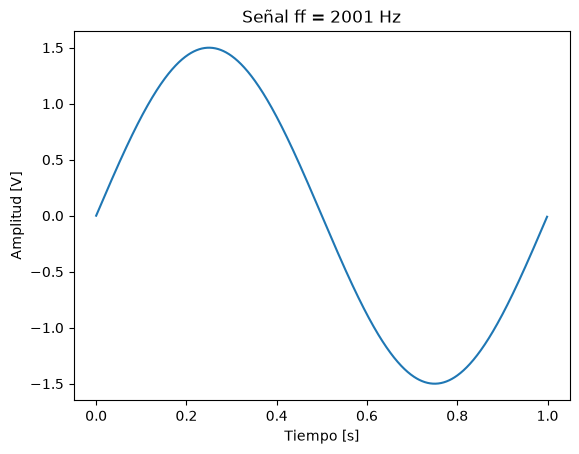

In [10]:
tt, xx = mi_funcion_sen( vmax = 1.5 , dc = 0, ff = 2001, ph=0, nn = N, fs = fs)
plt.plot(tt, xx) 
plt.title("Señal ff = 2001 Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.show()

usando 2.fs y |2001 − 2000| = 1 como referencia, con ff = 2001 Hz también aparece aliasing hacia 1 Hz. Al igual que en el caso de 1001 Hz, la señal arranca subiendo.

## Conclusión

A partir de las pruebas realizadas se puede ver que, mientras se respeta la condición de Nyquist (fs > 2·ff), la señal se representa correctamente, como en el caso de ff = 1 Hz. 
Al acercarse al límite (ff = 500 Hz = fs/2), la representación se vuelve poco confiable, ya que depende de en qué punto exacto caen las muestras.
Al superar ese límite (ff = 999, 1001 y 2001 Hz), aparece el fenómeno de aliasing: la señal muestreada no refleja su frecuencia real, sino una frecuencia mucho menor (en estos casos, 1 Hz), calculada como la diferencia entre la frecuencia real y el múltiplo de fs más cercano. Además, se observó que el sentido en que arranca la señal (subiendo o bajando) depende de si la frecuencia real está justo por debajo o por encima de ese múltiplo de fs.

En definitiva, la frecuencia de muestreo condiciona directamente qué señales se pueden representar sin ambigüedad, y trabajar cerca o por encima de fs/2 lleva a resultados poco confiables o directamente errados.